## Использование CPU и GPU на примере простой НС

На примере простейшей нейросети рассмотрим возможности фреймворка PyTorch производить вычисления на процессоре CPU и на графическом процессоре GPU.

Возьмем и дальше будем использовать пример из https://proproprogs.ru/

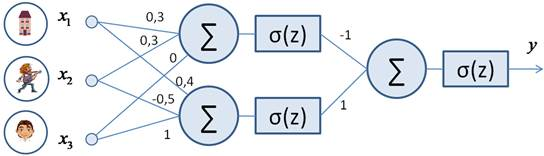

In [2]:
from IPython.display import Image

Image(filename='illustrations/GPU_1.jpg')

C ее помощью можно определить, нравится парень девушке или нет. На вход подавали:

- $x_1$ — наличие квартиры;
- $x_2$ — любит ли тяжелый рок;
- $x_3$ — красив или нет.

Если выходной сигнал $y=1$, то парень нравится девушке, в противном случае – не нравится. В качестве функции активации везде фигурировала пороговая функция вида:

$$
\sigma(z) = \begin{cases} 0, & z \ge 0.5 \\ 0, & z < 0.5 \end{cases}.
$$

Соответственно, выходные значения $U_h$ нейронов первого (скрытого) слоя можно посчитать с помощью векторно-матричных выражений:

$$
\begin{bmatrix} z_1 \\ z_2 \end{bmatrix} = \begin{bmatrix} 0.3 & 0.3 & 0 \\ 0.4 & -0.5 & 1 \end{bmatrix} \cdot \begin{bmatrix} x_1 \\ x_2 \\ x_3 \end{bmatrix}
$$

Общий вид вычислений для скрытого слоя:
$$
Z_h = W_h \cdot X
$$
$$
U_h = \sigma(Z_h)
$$

А итоговое выходное значение сети по формулам:
$$
[z_{out}] = [-1 \quad 1] \cdot \begin{bmatrix} u_1 \\ u_2 \end{bmatrix}
$$

Общий вид вычислений для выходного слоя:
$$
Z_{out} = W_{out} \cdot U_h
$$
$$
Y = \sigma(Z_{out})
$$

### 1. Перенос вычислений на GPU

Конечно, это очень простая нейронная сеть, которая с легкостью может быть посчитана центральным процессором компьютера. Однако на практике сети бывают гораздо, гораздо сложнее с десятками и сотнями миллионов нейронов и еще большим числом связей.  Вычисления таких сетей лучше оптимизировать. Для этого очень хорошо подходят графические процессоры (GPU – Graphics Processing Unit). Они оптимизированы для стандартных матричных операций.

Правда, поддержка реализована только для относительно новых видеокарт фирмы Nvidia. Итак, первым делом необходимо убедиться, что PyTorch имеет возможность взаимодействовать с GPU текущего устройства. В PyTorch имеется ветка torch.cuda, содержащая наборы функций для взаимодействия с GPU. В частности команда:

In [3]:
import torch

res = torch.cuda.is_available()
print(res)

False


Возвращает False, если поддержка GPU не настроена, и True – если GPU может быть использован пакетом PyTorch.

Вне зависимости от возможности использования GPU программу следует писать так, чтобы она корректно работала и с поддержкой GPU и без него. Для этого часто в программе определяют переменную вида:

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


Это устройство будет использоваться, при необходимости переноса вычислений на GPU, если он доступен, а иначе, все будет вычисляться центральным процессором.

Ранее, когда создавался тензор:

```python
w_out = torch.FloatTensor([-1, 1, -0.5])
```

То он по умолчанию размещается на CPU. Если же его нужно переместить (скопировать) на GPU, то можно воспользоваться методом to:

```python
w_out = w_out.to(device)
```

Либо сразу создать на GPU:

```python
w_out = torch.tensor([-1, 1, -0.5], device=device)
```

Также можно воспользоваться методом cuda:

```python
w_out = w_out.cuda()
```

Операции между тензорами можно выполнять, только если они располагаются **на одном процессоре**.

### 2. Пример реализации вычислений на GPU для НС

Конечно, для такой маленькой НС никакого выигрыша от использования GPU не будет. Возможно, даже программа будет работать дольше из-за дополнительного копирования тензоров на GPU. Но для крупных НС выигрыш тем больше, чем больше размер используемых в вычислениях тензоров.

In [5]:
def act(x):
    return 0 if x < 0.5 else 1


def go(house, rock, attr):
    X = torch.tensor([house, rock, attr], dtype=torch.float32)
    Wh = torch.tensor([[0.3, 0.3, 0], [0.4, -0.5, 1]]) # матрица 2x3
    Wout = torch.tensor([-1.0, 1.0]) # вектор 1х2

    Zh = torch.mv(Wh, X) # вычисляем сумму на входах нейронов скрытого слоя
    print(f"Значения сумм на нейронах скрытого слоя: {Zh}")

    Uh = torch.tensor([act(x) for x in Zh], dtype=torch.float32)
    print(f"Значения на выходах нейронов скрытого слоя: {Uh}")

    Zout = torch.dot(Wout, Uh)
    Y = act(Zout)
    print(f"Выходное значение НС: {Y}")

    return Y


house = 1
rock  = 0
attr  = 1

res = go(house, rock, attr)
if res == 1:
    print("Ты мне нравишься")
else:
    print("Созвонимся")

Значения сумм на нейронах скрытого слоя: tensor([0.3000, 1.4000])
Значения на выходах нейронов скрытого слоя: tensor([0., 1.])
Выходное значение НС: 1
Ты мне нравишься
